<a href="https://colab.research.google.com/github/Nishanta04/Model-Training-on-Real-World-Data/blob/main/IRIS_Perceptron_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
iris = pd.read_csv('/content/Iris.csv')

In [3]:
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
pd.DataFrame(iris)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [7]:
type(iris)

pandas.core.frame.DataFrame

In [9]:
iris.shape

(150, 6)

In [13]:
iris['target_setosa']     = np.where(iris['Species'] == 'Iris-setosa', 1, -1)
iris['target_versicolor'] = np.where(iris['Species'] == 'Iris-versicolor', 1, -1)
iris['target_virginica']  = np.where(iris['Species'] == 'Iris-virginica', 1, -1)

In [14]:
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,target_setosa,target_versicolor,target_virginica
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1,-1,-1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1,-1,-1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1,-1,-1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1,-1,-1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1,-1,-1
...,...,...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica,-1,-1,1
146,147,6.3,2.5,5.0,1.9,Iris-virginica,-1,-1,1
147,148,6.5,3.0,5.2,2.0,Iris-virginica,-1,-1,1
148,149,6.2,3.4,5.4,2.3,Iris-virginica,-1,-1,1


In [15]:
X = iris.iloc[:, 1:5].values

y_setosa     = iris['target_setosa'].values
y_versicolor = iris['target_versicolor'].values
y_virginica  = iris['target_virginica'].values

In [17]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [47]:
def perceptron(X, y, epochs=20, lr=0.01):
    w1 = w2 = w3 = w4 = b = 1
    errors_per_epoch = []

    for j in range(epochs):
        count = 0
        for i in range(X.shape[0]):
            z = w1*X[i][0] + w2*X[i][1] + w3*X[i][2] + w4*X[i][3] + b

            if z * y[i] <= 0:
                count += 1
                w1 = w1 + lr*y[i]*X[i][0]
                w2 = w2 + lr*y[i]*X[i][1]
                w3 = w3 + lr*y[i]*X[i][2]
                w4 = w4 + lr*y[i]*X[i][3]
                b  = b  + lr*y[i]

        errors_per_epoch.append(count)

    return w1, w2, w3, w4, b, errors_per_epoch

In [51]:
w1_s, w2_s, w3_s, w4_s, b_s, errors_setosa = perceptron(X,y_setosa)
w1_v, w2_v, w3_v, w4_v, b_v, errors_versicolor = perceptron(X,y_versicolor)
w1_g, w2_g, w3_g, w4_g, b_g, errors_virginica = perceptron(X,y_virginica)


In [52]:
print(w1_s,w2_s,w3_s,w4_s,b_s,errors_setosa)
print(w1_v,w2_v,w3_v,w4_v,b_v,errors_versicolor)
print(w1_g,w2_g,w3_g,w4_g,b_g,errors_virginica)


-0.3410000000000004 0.48399999999999954 -0.2990000000000002 0.5409999999999996 0.7999999999999998 [25, 5, 3, 4, 3, 2, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
-0.3239999999999994 -0.022000000000000325 -0.0680000000000006 0.48799999999999955 0.6699999999999997 [34, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 4, 6, 4, 4, 4, 4, 4, 4]
-0.6590000000000029 -0.24600000000000036 0.6519999999999996 0.957 0.6499999999999997 [35, 4, 3, 4, 4, 3, 2, 4, 4, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4]


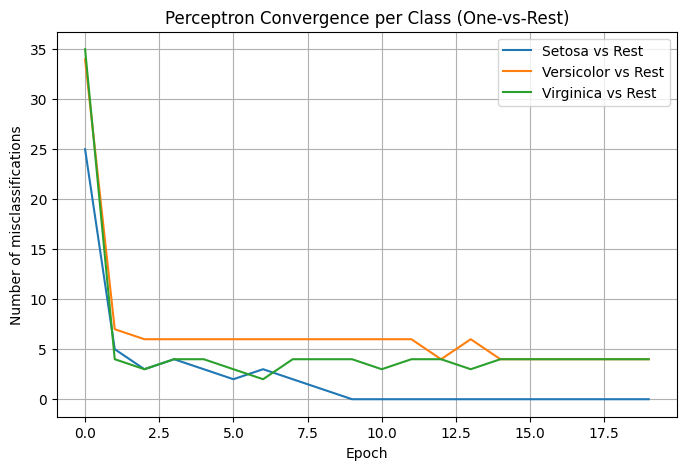

In [53]:
plt.figure(figsize=(8,5))
plt.plot(errors_setosa, label='Setosa vs Rest')
plt.plot(errors_versicolor, label='Versicolor vs Rest')
plt.plot(errors_virginica, label='Virginica vs Rest')

plt.xlabel('Epoch')
plt.ylabel('Number of misclassifications')
plt.title('Perceptron Convergence per Class (One-vs-Rest)')
plt.legend()
plt.grid(True)
plt.show()